# Inference with GGUF Model

This notebook focuses entirely on running inference using the `llama-cpp-python` package. 

Before running this notebook, ensure you have successfully compiled and converted your model by running the following command in the main `FYP` folder:
```bash
python llama.cpp/convert_hf_to_gguf.py ./merged_model_16bit --outfile gguf_model/unsloth.Q8_0.gguf --outtype q8_0
```

In [ ]:


import time
from llama_cpp import Llama

model_load_start = time.perf_counter()
llm = Llama(
    model_path="gguf_model/unsloth.q4_k_m.gguf",
    n_ctx=2048,
    n_gpu_layers=-1,
    verbose=False  # Explicitly enable verbose logging
)
model_load_time = time.perf_counter() - model_load_start

print(f"✅ GGUF model loaded successfully in {model_load_time:.2f} seconds.")

llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


✅ GGUF model loaded successfully in 0.68 seconds.


/home/sachithra/miniconda3/envs/unsloth_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded test split with 62900 rows.
Running generation benchmark for 100 test cases...
Case 001/100: 9.16 seconds (attempt 1)
Case 002/100: 11.85 seconds (attempt 1)
Case 003/100: 11.53 seconds (attempt 1)
Case 004/100: 0.73 seconds (attempt 1)
Case 005/100: 11.32 seconds (attempt 1)
Case 006/100: 0.79 seconds (attempt 1)
Case 007/100: 11.47 seconds (attempt 1)
Case 008/100: 3.39 seconds (attempt 1)
Case 009/100: 0.85 seconds (attempt 1)
Case 010/100: 0.71 seconds (attempt 1)
Case 011/100: 4.91 seconds (attempt 1)
Case 012/100: 11.85 seconds (attempt 1)
Case 013/100: 11.83 seconds (attempt 1)
Case 014/100: 0.74 seconds (attempt 1)
Case 015/100: 0.65 seconds (attempt 1)
Case 016/100: 11.52 seconds (attempt 1)
Case 017/100: 11.51 seconds (attempt 1)
Case 018/100: 11.84 seconds (attempt 1)
Case 019/100: 0.66 seconds (attempt 1)
Case 020/100: 11.72 seconds (attempt 1)
Case 021/100: 0.73 seconds (attempt 1)
Case 022/100: 0.80 seconds (attempt 1)
Case 023/100: 0.79 seconds (attempt 1)
Case 02

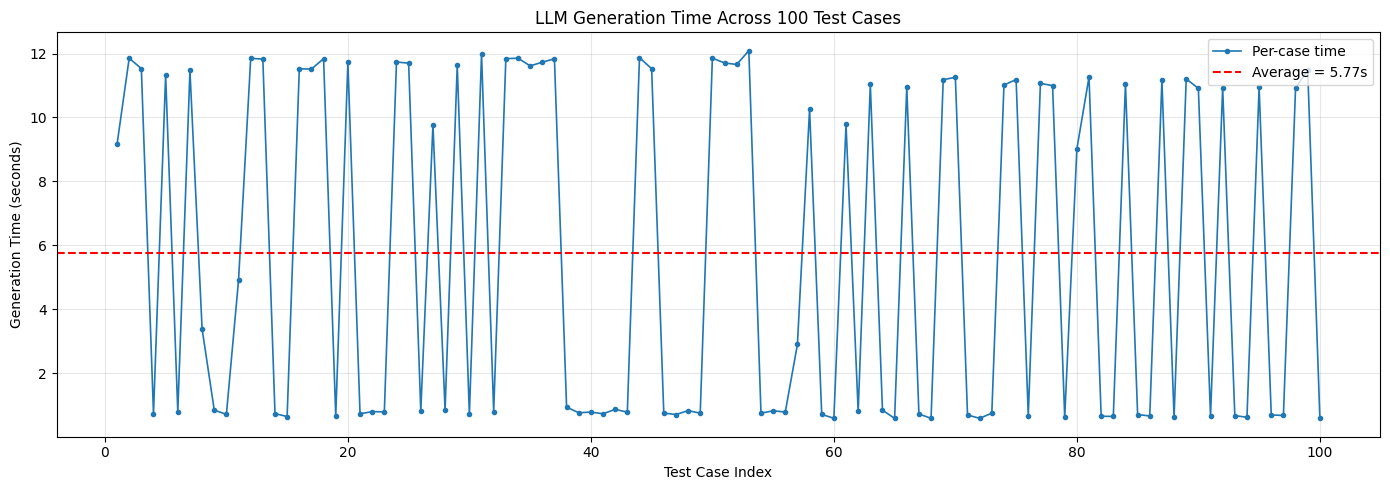

In [ ]:
import statistics
import time
import matplotlib.pyplot as plt
from datasets import load_dataset

test_dataset = load_dataset("KAKA22/CodeRM-UnitTest", split="test")
num_cases = min(100, len(test_dataset))

print(f"Loaded test split with {len(test_dataset)} rows.")
print(f"Running generation benchmark for {num_cases} test cases...")

def truncate_text_middle(text, max_chars):
    """Trim long text while preserving both prefix and suffix context."""
    if not isinstance(text, str):
        text = str(text)
    text = text.strip()
    if len(text) <= max_chars:
        return text

    head = max_chars // 2
    tail = max_chars - head
    return (
        text[:head]
        + "\n\n# ... content truncated to fit model context window ...\n\n"
        + text[-tail:]
    )

def build_user_prompt(example, max_code_chars=3500, max_description_chars=700):
    """Create a robust user prompt from varying dataset schemas."""
    code_keys = ["code", "source_code", "input_code", "function", "snippet", "program", "solution"]
    description_keys = ["problem", "description", "prompt", "question", "instruction", "task"]

    code_text = ""
    for key in code_keys:
        value = example.get(key)
        if isinstance(value, str) and value.strip():
            code_text = value
            break

    description_text = ""
    for key in description_keys:
        value = example.get(key)
        if isinstance(value, str) and value.strip():
            description_text = value
            break

    if not code_text:
        string_values = [value for value in example.values() if isinstance(value, str) and value.strip()]
        if string_values:
            code_text = max(string_values, key=len)
        else:
            code_text = str(example)

    if not description_text:
        description_text = "Generate a comprehensive Python unit test suite for the given code."

    code_text = truncate_text_middle(code_text, max_code_chars)
    description_text = truncate_text_middle(description_text, max_description_chars)

    return (
        "Write a comprehensive Python unit test suite for this code.\n\n"
        f"Problem Description:\n{description_text}\n\n"
        f"Code to Test:\n{code_text}"
    )

def generate_for_case(user_prompt, max_tokens=512, temperature=0.7, top_p=0.9):
    """Run a single case with an isolated context."""
    messages = [
        {"role": "system", "content": "You are a helpful coding assistant that writes Python unit tests."},
        {"role": "user", "content": user_prompt},
    ]

    if hasattr(llm, "reset"):
        llm.reset()  # Ensure each case starts from a fresh KV cache/context.

    return llm.create_chat_completion(
        messages=messages,
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
    )

generation_times = []
generated_tests = []
case_indices = []


prompt_budgets = [
    (3500, 700),
    (2200, 500),
    (1400, 300),
]

for idx in range(num_cases):
    sample = test_dataset[idx]

    start_time = time.perf_counter()
    output = None
    attempt_used = 0

    for attempt_used, (max_code_chars, max_description_chars) in enumerate(prompt_budgets, start=1):
        user_prompt = build_user_prompt(
            sample,
            max_code_chars=max_code_chars,
            max_description_chars=max_description_chars,
        )
        try:
            output = generate_for_case(
                user_prompt,
                max_tokens=512,
                temperature=0.7,
                top_p=0.9,
            )
            break
        except ValueError as err:
            if "exceed context window" in str(err):
                continue
            raise

    elapsed = time.perf_counter() - start_time

    if output is None:
        print(
            f"Case {idx + 1:03d}/{num_cases}: skipped after {attempt_used} attempts (context window overflow)."
        )
        continue

    generation_times.append(elapsed)
    case_indices.append(idx + 1)
    generated_tests.append(output["choices"][0]["message"]["content"].strip())
    print(f"Case {idx + 1:03d}/{num_cases}: {elapsed:.2f} seconds (attempt {attempt_used})")

if not generation_times:
    raise RuntimeError("No generations completed successfully; all prompts exceeded the model context window.")

avg_time = statistics.mean(generation_times)
median_time = statistics.median(generation_times)
min_time = min(generation_times)
max_time = max(generation_times)

print("\nGeneration time summary (seconds):")
print(f"Completed cases: {len(generation_times)} / {num_cases}")
print(f"Average: {avg_time:.2f}")
print(f"Median : {median_time:.2f}")
print(f"Min    : {min_time:.2f}")
print(f"Max    : {max_time:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(case_indices, generation_times, marker="o", markersize=3, linewidth=1.2, label="Per-case time")
plt.axhline(avg_time, color="red", linestyle="--", linewidth=1.5, label=f"Average = {avg_time:.2f}s")
plt.title(f"LLM Generation Time Across {len(generation_times)} Test Cases")
plt.xlabel("Test Case Index")
plt.ylabel("Generation Time (seconds)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()